# SPARK ASSIGNMENT 3 ARVE MOHAN GARG 202400034

In [2]:
!pip install pyspark -q

In [3]:
# Import required libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count

# Create Spark Session
spark = SparkSession.builder \
    .appName("ProductSalesByCategory") \
    .getOrCreate()

# File path
file_path = "/content/shopping_trends_updated.csv"

# Read CSV file
df = spark.read.csv(
    file_path,
    header=True,
    inferSchema=True
)

# Display first few rows
df.show(5)

# Display column names
print("Columns:")
print(df.columns)

+-----------+---+------+--------------+--------+---------------------+-------------+----+---------+------+-------------+-------------------+-------------+----------------+---------------+------------------+--------------+----------------------+
|Customer ID|Age|Gender|Item Purchased|Category|Purchase Amount (USD)|     Location|Size|    Color|Season|Review Rating|Subscription Status|Shipping Type|Discount Applied|Promo Code Used|Previous Purchases|Payment Method|Frequency of Purchases|
+-----------+---+------+--------------+--------+---------------------+-------------+----+---------+------+-------------+-------------------+-------------+----------------+---------------+------------------+--------------+----------------------+
|          1| 55|  Male|        Blouse|Clothing|                   53|     Kentucky|   L|     Gray|Winter|          3.1|                Yes|      Express|             Yes|            Yes|                14|         Venmo|           Fortnightly|
|          2| 19|  M

In [4]:
# Calculate number of products sold in each category

category_sales = df.groupBy("Category") \
    .agg(count("*").alias("Number_of_Products_Sold")) \
    .orderBy(col("Number_of_Products_Sold").desc())

# Display result
category_sales.show()

+-----------+-----------------------+
|   Category|Number_of_Products_Sold|
+-----------+-----------------------+
|   Clothing|                   1737|
|Accessories|                   1240|
|   Footwear|                    599|
|  Outerwear|                    324|
+-----------+-----------------------+



In [5]:
# Convert Spark DataFrame to Pandas DataFrame for visualization

category_df = category_sales.toPandas()

# Display the data
print(category_df)

      Category  Number_of_Products_Sold
0     Clothing                     1737
1  Accessories                     1240
2     Footwear                      599
3    Outerwear                      324


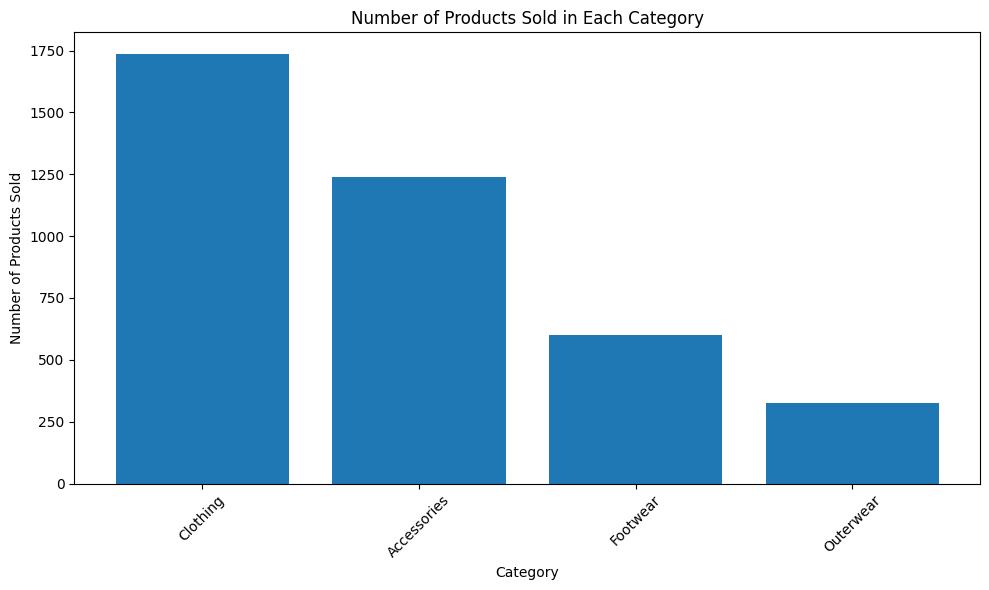

In [6]:
import matplotlib.pyplot as plt

# Create Bar Chart
plt.figure(figsize=(10, 6))

plt.bar(
    category_df["Category"],
    category_df["Number_of_Products_Sold"]
)

plt.title("Number of Products Sold in Each Category")
plt.xlabel("Category")
plt.ylabel("Number of Products Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

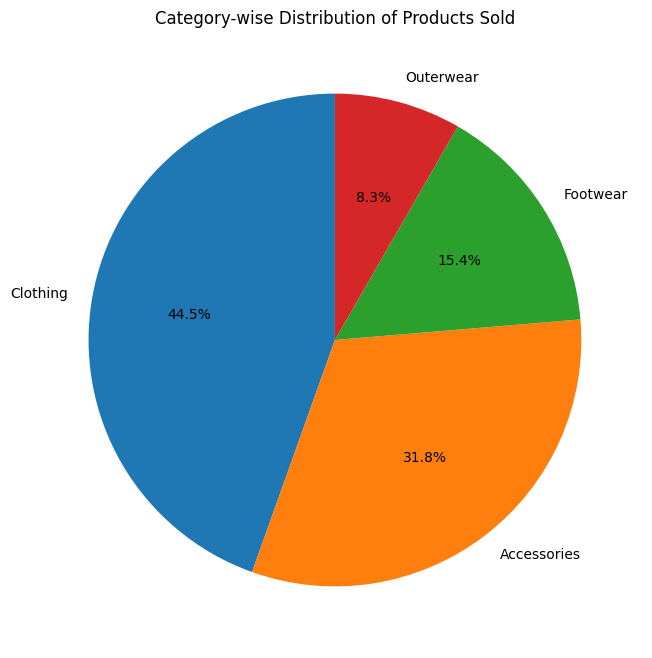

In [7]:
# Create Pie Chart
plt.figure(figsize=(8, 8))

plt.pie(
    category_df["Number_of_Products_Sold"],
    labels=category_df["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Category-wise Distribution of Products Sold")

plt.show()

In [8]:
# Find highest selling category

highest_category = category_sales.first()

print("Highest Selling Category:",
      highest_category["Category"])

print("Number of Products Sold:",
      highest_category["Number_of_Products_Sold"])

Highest Selling Category: Clothing
Number of Products Sold: 1737


In [9]:
# Find lowest selling category

lowest_category = category_sales.orderBy(
    col("Number_of_Products_Sold").asc()
).first()

print("Lowest Selling Category:",
      lowest_category["Category"])

print("Number of Products Sold:",
      lowest_category["Number_of_Products_Sold"])

Lowest Selling Category: Outerwear
Number of Products Sold: 324


In [10]:
# Calculate total number of products sold

total_products = df.count()

print("Total Number of Products Sold:", total_products)

Total Number of Products Sold: 3900


In [11]:
from pyspark.sql.functions import round

category_percentage = category_sales.withColumn(
    "Percentage",
    round(
        (col("Number_of_Products_Sold") / total_products) * 100,
        2
    )
)

category_percentage.show()

+-----------+-----------------------+----------+
|   Category|Number_of_Products_Sold|Percentage|
+-----------+-----------------------+----------+
|   Clothing|                   1737|     44.54|
|Accessories|                   1240|     31.79|
|   Footwear|                    599|     15.36|
|  Outerwear|                    324|      8.31|
+-----------+-----------------------+----------+



In [12]:
print("========== SALES ANALYSIS SUMMARY ==========")

print("Total Products Sold:", total_products)

print(
    "Highest Selling Category:",
    highest_category["Category"],
    "-",
    highest_category["Number_of_Products_Sold"]
)

print(
    "Lowest Selling Category:",
    lowest_category["Category"],
    "-",
    lowest_category["Number_of_Products_Sold"]
)

print("============================================")

========== SALES ANALYSIS SUMMARY ==========
Total Products Sold: 3900
Highest Selling Category: Clothing - 1737
Lowest Selling Category: Outerwear - 324
